In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ETAPA DE DADOS - Baixando a base de dados para a pasta raw

In [1]:
from sklearn.datasets import fetch_openml

print("Baixando o dataset MNIST...")

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto",
    data_home="../data/raw"
)

print("Finalizou o download do dataset MNIST!")

Baixando o dataset MNIST...
Finalizou o download do dataset MNIST!


ETAPA DE ANÁLISE

In [3]:
X = mnist.data
y = mnist.target.astype(int)

print(f"Dimensões de X: {X.shape}")
print(f"Dimensões de y: {y.shape}")

classes, contagens = np.unique(y, return_counts=True)

distribuicao = pd.DataFrame({
    "Classe": classes,
    "Quantidade": contagens,
    "Percentual (%)": (contagens / len(y) * 100).round(2)
})

display(distribuicao)

diferenca = contagens.max() - contagens.min()
variacao_percentual = diferenca / contagens.max() * 100

print(f"Classes identificadas: {classes}")
print(f"Maior classe: {contagens.max()} exemplos")
print(f"Menor classe: {contagens.min()} exemplos")
print(f"Diferença: {diferenca} exemplos")
print(f"Variação entre maior e menor classe: {variacao_percentual:.2f}%")

Dimensões de X: (70000, 784)
Dimensões de y: (70000,)


,Classe,Quantidade,Percentual (%)
0,0,6903,9.86
1,1,7877,11.25
2,2,6990,9.99
3,3,7141,10.20
4,4,6824,9.75
5,5,6313,9.02
6,6,6876,9.82
7,7,7293,10.42
8,8,6825,9.75
9,9,6958,9.94


Classes identificadas: [0 1 2 3 4 5 6 7 8 9]
Maior classe: 7877 exemplos
Menor classe: 6313 exemplos
Diferença: 1564 exemplos
Variação entre maior e menor classe: 19.86%


Conclusão: O conjunto contém todas as classes esperadas, representando os dígitos de 0 a 9. Embora exista uma variação de 19,86% entre a classe mais e a menos frequente, nenhuma classe apresenta baixa representatividade. Portanto, o dataset pode ser considerado suficientemente balanceado, não sendo necessário aplicar técnicas de reamostragem. Por meio da estratificação essa distribuição será preservada.

ETAPA - Criar visualização dos dado

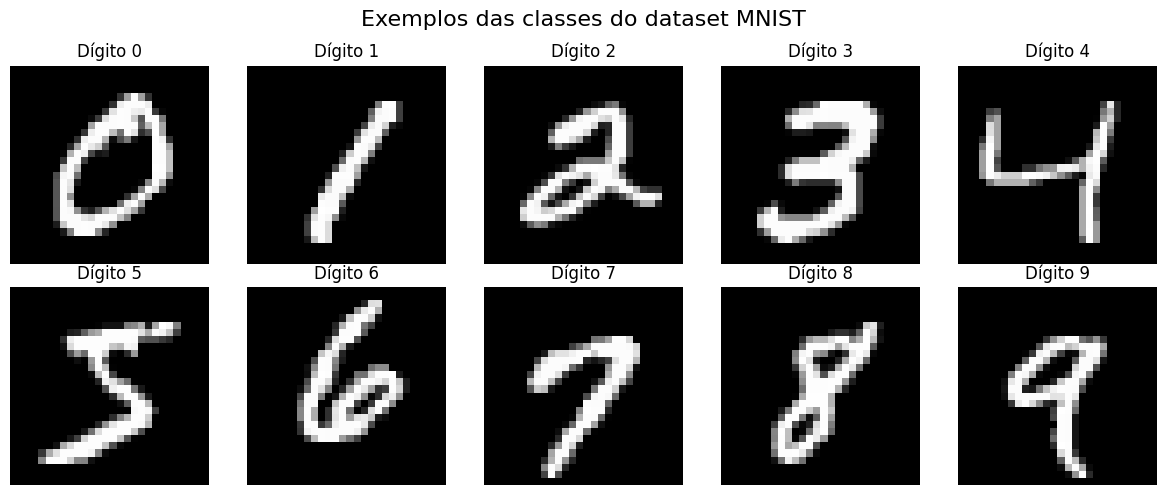

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for classe, eixo in zip(classes, axes.ravel()):
    indice = np.flatnonzero(y == classe)[0]
    imagem = X[indice].reshape(28, 28)

    eixo.imshow(imagem, cmap="gray")
    eixo.set_title(f"Dígito {classe}")
    eixo.axis("off")

fig.suptitle("Exemplos das classes do dataset MNIST", fontsize=16)
plt.tight_layout()
plt.show()